# Are features 438 and 1797 CWE-domain detectors or language detectors?

**Question:** Do these features fire because of the CWE domain (injection / memory), or simply because of the programming language that happens to be dominant for that domain?

We measure `P(feature active | CWE)` and try to decompose how much of that is explained by `P(feature active | language)` vs. a genuine CWE-type effect.

**Key dataset constraint:**
- Memory CWEs → ~97% C code
- Injection CWEs → ~73% PHP, ~16% JS

Language and CWE type are highly correlated, so we need controlled comparisons:

| Test | What it controls | What it varies |
|---|---|---|
| Within-language CWE comparison | Language | CWE type |
| Cross-language CWE comparison | CWE type | Language |
| GLM with both predictors | Neither | Both simultaneously |

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# ── CONFIG ──────────────────────────────────────────────────────────────────
FEATURES  = [438, 1797]           # features to analyse together
LAYER     = 11
RUN_ID    = "run_20260218_134529_vulnerable_code_qwen_coder_standard_16384_10M"
EPSILON   = 1e-6                  # threshold to count a feature as "active"
# ────────────────────────────────────────────────────────────────────────────

MEMORY_CWES    = {"CWE-119", "CWE-125", "CWE-787", "CWE-416", "CWE-401", "CWE-190", "CWE-476",
                  "CWE-120", "CWE-189", "CWE-415", "CWE-369"}
INJECTION_CWES = {"CWE-89",  "CWE-79",  "CWE-94",  "CWE-78",  "CWE-352", "CWE-434"}
C_FAMILY       = {"c", "cc", "cpp", "h", "cxx"}
PHP_JS_FAMILY  = {"php", "js", "ts"}

In [3]:
import glob
import orjson
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from scipy.stats import mannwhitneyu, kruskal
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder

## Load data

We pool secure and vulnerable samples — this analysis is purely about **domain detection** (`P(feature | CWE type)`), not vulnerability detection.

In [4]:
files = sorted(glob.glob(
    f"../../artifacts/activations/{RUN_ID}/activations_layer_{LAYER}_*.jsonl"
))
print(f"Files: {files}")

records = []
with open(files[0]) as f:
    for line in tqdm(f, desc="Loading"):
        d   = orjson.loads(line)
        ext = d["file_extension"].lower().lstrip(".")
        cwe = d["cwe"]
        fam = ("memory"    if cwe in MEMORY_CWES
               else "injection" if cwe in INJECTION_CWES
               else "other")

        base = dict(
            vuln_id    = d["vuln_id"],
            cwe        = cwe,
            lang       = ext,
            cwe_family = fam,
            is_c       = ext in C_FAMILY,
            is_php_js  = ext in PHP_JS_FAMILY,
        )

        for label_key, label in [("secure", 0), ("vulnerable", 1)]:
            acts = d[label_key]
            row  = {**base, "label": label}
            for feat in FEATURES:
                row[f"f{feat}_val"]    = acts[feat]
                row[f"f{feat}_active"] = int(acts[feat] > EPSILON)
            records.append(row)

df = pd.DataFrame(records)

print(f"\nTotal rows (both labels): {len(df)}")
print(df.groupby(["cwe_family", "lang"])["vuln_id"]
        .count().unstack(fill_value=0))

Files: ['../../artifacts/activations/run_20260218_134529_vulnerable_code_qwen_coder_standard_16384_10M/activations_layer_11_sae_blocks.11.hook_resid_post_component_hook_resid_post.hook_sae_acts_post.jsonl']


Loading: 0it [00:00, ?it/s]


Total rows (both labels): 4986
lang           c   cc  cpp  cs  go  html  java   js  php  py  rb  rs  ts  xml
cwe_family                                                                   
injection     16    2    4   8  14    20    24  172  836  46  40   0  20    6
memory      1986  316   94   0   6     0     6    4    8   0   0  16   0    0
other        734   34   50   8  32     0    58  126  192  64  18  16   8    2


---
## Part 1: Baseline — P(feature active | CWE) and P(feature active | language)

Reproduce and extend the co-activation heatmap. We pool both labels since we are asking about domain detection, not vulnerability detection.

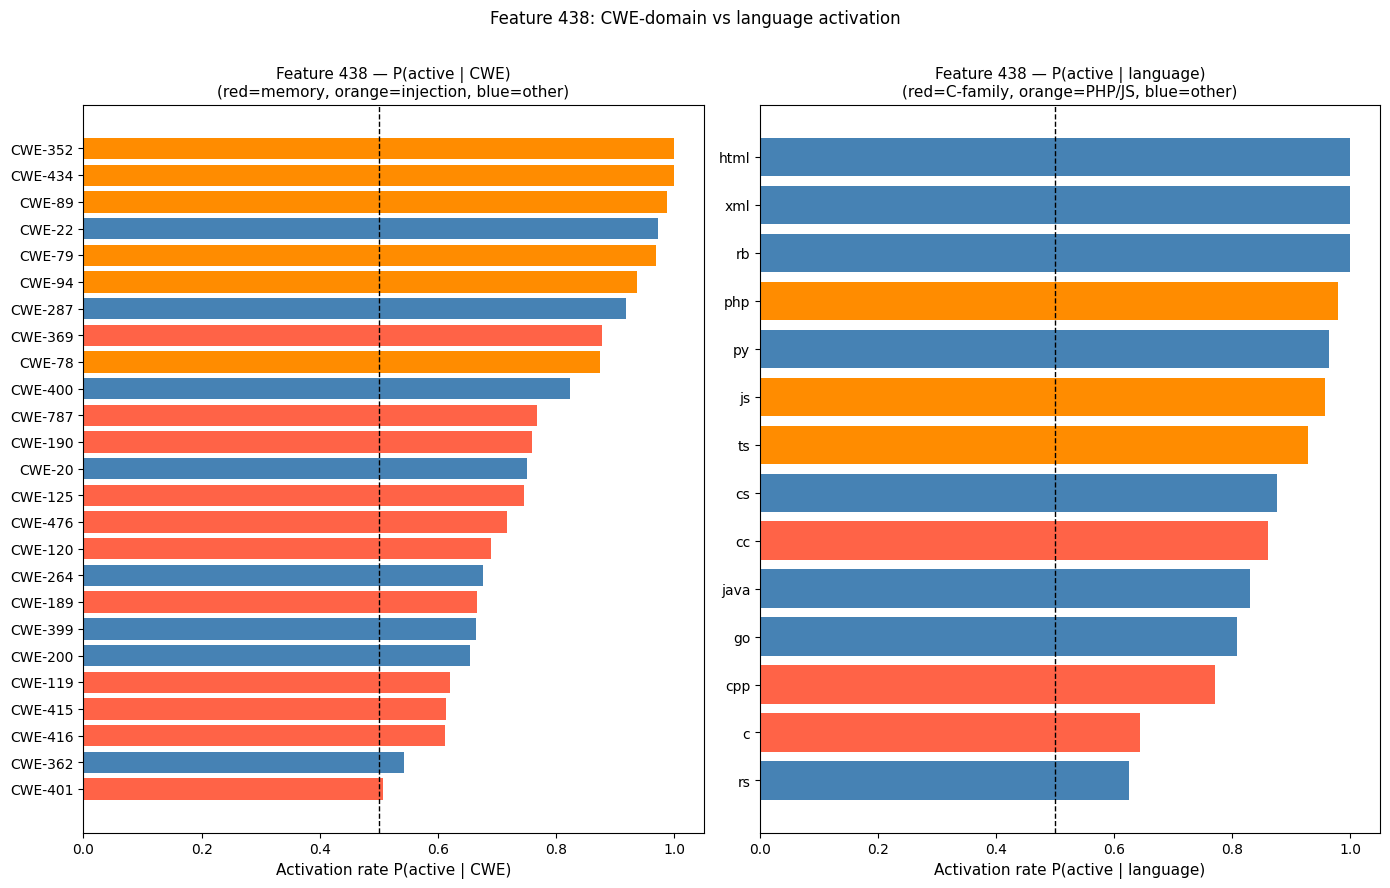


Feature 438 — top 5 CWEs by activation rate:
cwe
CWE-352    1.000000
CWE-434    1.000000
CWE-89     0.988095
CWE-22     0.973684
CWE-79     0.968992

Feature 438 — top 5 languages by activation rate:
lang
html    1.000000
xml     1.000000
rb      1.000000
php     0.978764
py      0.963636



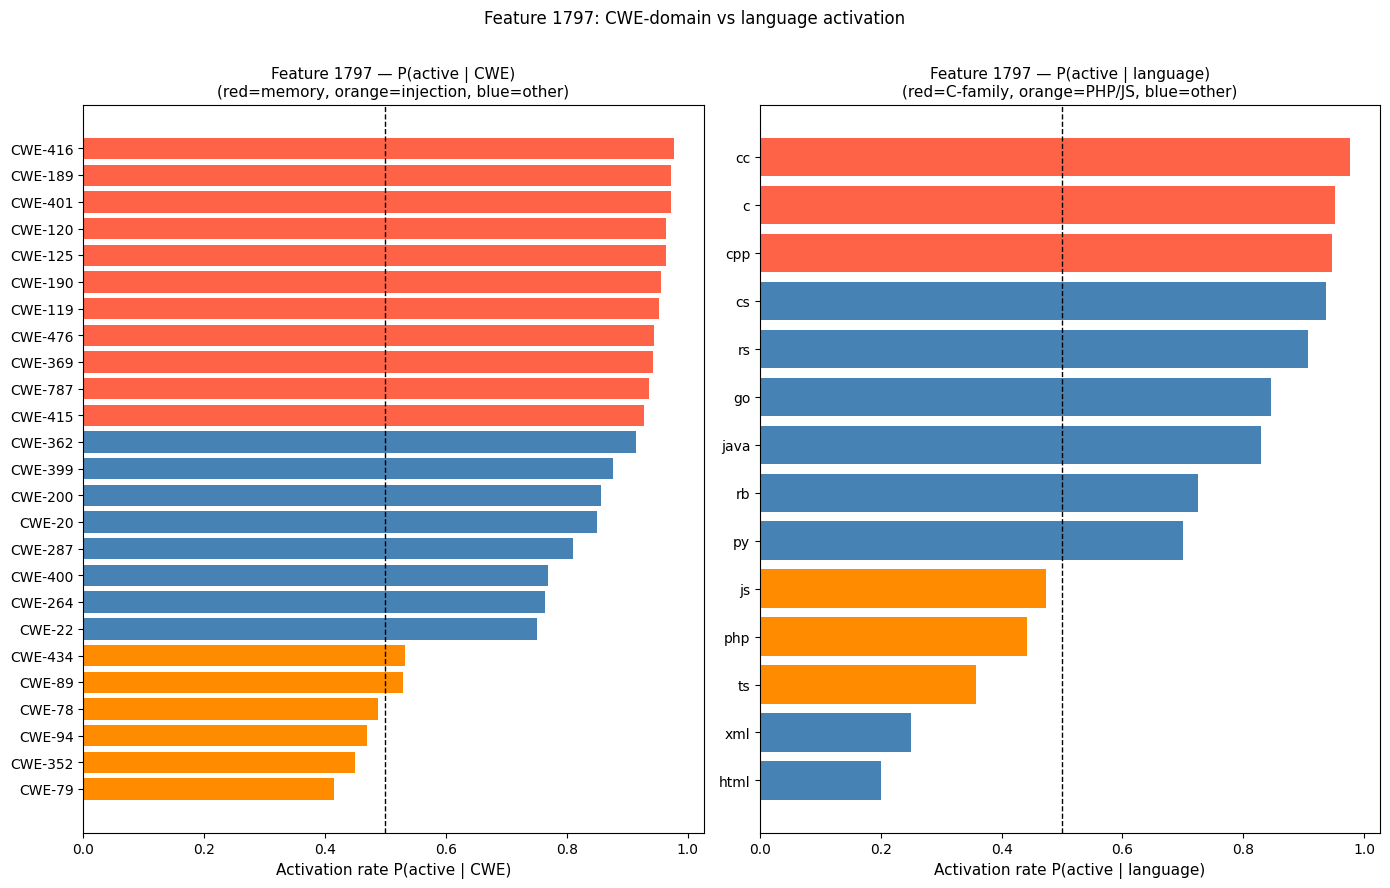


Feature 1797 — top 5 CWEs by activation rate:
cwe
CWE-416    0.977679
CWE-189    0.972222
CWE-401    0.971831
CWE-120    0.964286
CWE-125    0.963636

Feature 1797 — top 5 languages by activation rate:
lang
cc     0.977273
c      0.951023
cpp    0.945946
cs     0.937500
rs     0.906250



In [5]:
for feat in FEATURES:
    act_col = f"f{feat}_active"

    # P(active | CWE)
    by_cwe = (df.groupby("cwe")[act_col].mean()
                .sort_values(ascending=False)
                .rename(f"F{feat}"))

    # P(active | language)
    by_lang = (df.groupby("lang")[act_col].mean()
                 .sort_values(ascending=False)
                 .rename(f"F{feat}"))

    fig, axes = plt.subplots(1, 2, figsize=(14, max(4, len(by_cwe)*0.35)))

    # color bars by CWE family
    cwe_colors = ["tomato" if c in MEMORY_CWES
                  else "darkorange" if c in INJECTION_CWES
                  else "steelblue"
                  for c in by_cwe.index]
    axes[0].barh(by_cwe.index, by_cwe.values, color=cwe_colors)
    axes[0].axvline(0.5, color="black", linestyle="--", lw=1)
    axes[0].set_xlabel("Activation rate P(active | CWE)", fontsize=11)
    axes[0].set_title(f"Feature {feat} — P(active | CWE)\n"
                      "(red=memory, orange=injection, blue=other)", fontsize=11)
    axes[0].invert_yaxis()

    lang_colors = ["tomato" if l in C_FAMILY
                   else "darkorange" if l in PHP_JS_FAMILY
                   else "steelblue"
                   for l in by_lang.index]
    axes[1].barh(by_lang.index, by_lang.values, color=lang_colors)
    axes[1].axvline(0.5, color="black", linestyle="--", lw=1)
    axes[1].set_xlabel("Activation rate P(active | language)", fontsize=11)
    axes[1].set_title(f"Feature {feat} — P(active | language)\n"
                      "(red=C-family, orange=PHP/JS, blue=other)", fontsize=11)
    axes[1].invert_yaxis()

    plt.suptitle(f"Feature {feat}: CWE-domain vs language activation", fontsize=12, y=1.01)
    plt.tight_layout()
    plt.savefig(f"cwe_domain_baseline_f{feat}.png", dpi=150)
    plt.show()

    print(f"\nFeature {feat} — top 5 CWEs by activation rate:")
    print(by_cwe.head(5).to_string())
    print(f"\nFeature {feat} — top 5 languages by activation rate:")
    print(by_lang.head(5).to_string())
    print()

---
## Part 2: Within-language CWE test  *(controls for language)*

The decisive test for whether a feature is a CWE-domain detector vs. a language detector.

**Feature 438 (injection hypothesis):** Within PHP-only samples, compare activation for injection CWEs vs. non-injection CWEs. If it's just a PHP detector, both should be equally high.

**Feature 1797 (memory hypothesis):** Within C-only samples, compare activation for memory CWEs vs. non-memory CWEs. If it's just a C detector, both should be equally high.

In [6]:
def within_lang_cwe_test(df, feat, lang_filter, target_family, label=""):
    """Within a fixed language, compare activation across CWE families."""
    sub    = df[df["lang"].isin(lang_filter) if isinstance(lang_filter, set)
                else df["lang"] == lang_filter]
    val    = f"f{feat}_val"
    target = sub[sub["cwe_family"] == target_family][val].values
    other  = sub[sub["cwe_family"] != target_family][val].values

    if len(target) < 5 or len(other) < 5:
        print(f"  Not enough data (target={len(target)}, other={len(other)})")
        return

    stat, p = mannwhitneyu(target, other, alternative="two-sided")
    print(f"  {label}")
    print(f"    {target_family:12s}: n={len(target):4d}  mean={target.mean():.4f}  std={target.std():.4f}")
    print(f"    other CWEs   : n={len(other):4d}  mean={other.mean():.4f}  std={other.std():.4f}")
    print(f"    Mann-Whitney p = {p:.4f}")
    effect = (target.mean() - other.mean()) / (np.sqrt((target.std()**2 + other.std()**2)/2) + 1e-12)
    print(f"    Cohen's d = {effect:.3f}")
    if p < 0.05 and abs(effect) > 0.2:
        print(f"    → Significant CWE-family effect WITHIN this language → CWE-domain detector.")
    elif p < 0.05:
        print(f"    → Significant but small effect.")
    else:
        print(f"    → No significant difference → language detector (CWE type adds no information).")
    print()
    return target, other


print("=" * 65)
print("FEATURE 438 — within PHP/JS: injection vs. non-injection CWEs")
print("=" * 65)
r438_php = within_lang_cwe_test(df, 438, {"php"}, "injection", label="PHP only")
r438_js  = within_lang_cwe_test(df, 438, {"js", "ts"}, "injection", label="JS/TS only")
r438_all = within_lang_cwe_test(df, 438, PHP_JS_FAMILY, "injection", label="All PHP/JS/TS")

print("=" * 65)
print("FEATURE 1797 — within C family: memory vs. non-memory CWEs")
print("=" * 65)
r1797_c  = within_lang_cwe_test(df, 1797, C_FAMILY, "memory", label="C-family only")

FEATURE 438 — within PHP/JS: injection vs. non-injection CWEs
  PHP only
    injection   : n= 836  mean=0.6278  std=0.3310
    other CWEs   : n= 200  mean=0.5111  std=0.2682
    Mann-Whitney p = 0.0000
    Cohen's d = 0.387
    → Significant CWE-family effect WITHIN this language → CWE-domain detector.

  JS/TS only
    injection   : n= 192  mean=0.5425  std=0.3014
    other CWEs   : n= 138  mean=0.4927  std=0.2965
    Mann-Whitney p = 0.1872
    Cohen's d = 0.167
    → No significant difference → language detector (CWE type adds no information).

  All PHP/JS/TS
    injection   : n=1028  mean=0.6118  std=0.3274
    other CWEs   : n= 338  mean=0.5036  std=0.2802
    Mann-Whitney p = 0.0000
    Cohen's d = 0.355
    → Significant CWE-family effect WITHIN this language → CWE-domain detector.

FEATURE 1797 — within C family: memory vs. non-memory CWEs
  C-family only
    memory      : n=2396  mean=0.4543  std=0.3348
    other CWEs   : n= 840  mean=0.4201  std=0.3234
    Mann-Whitney p = 0

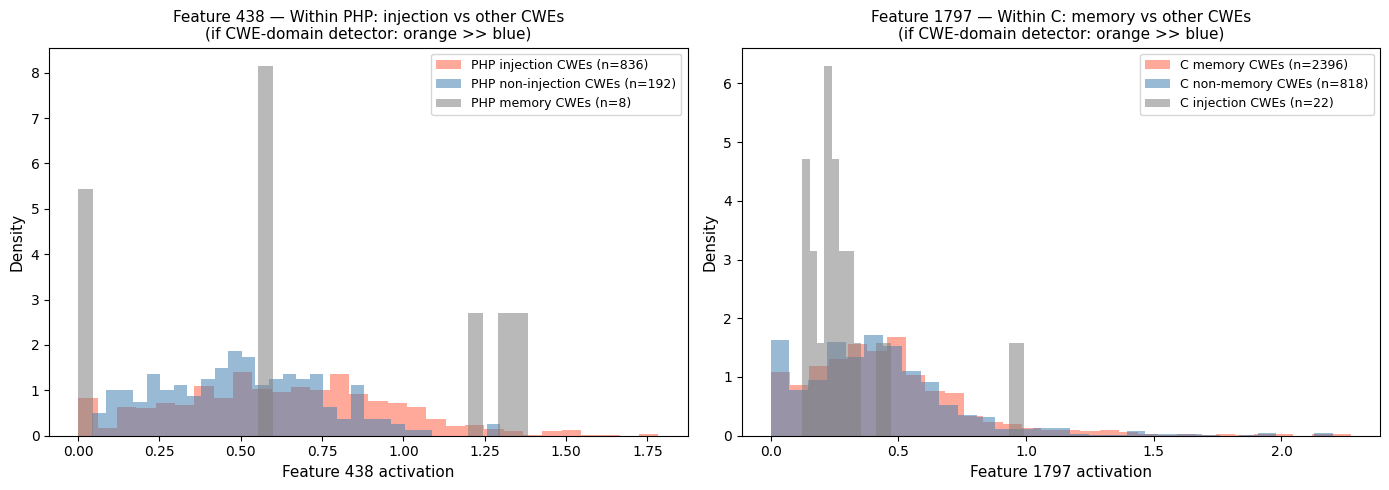

In [7]:
# Visualise the within-language distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Feature 438 within PHP
php_df = df[df["lang"] == "php"]
for fam, color, label in [("injection", "tomato", "PHP injection CWEs"),
                           ("other",     "steelblue", "PHP non-injection CWEs"),
                           ("memory",    "gray",      "PHP memory CWEs")]:
    sub = php_df[php_df["cwe_family"] == fam]["f438_val"].values
    if len(sub) > 0:
        axes[0].hist(sub, bins=30, alpha=0.55, density=True, color=color,
                     label=f"{label} (n={len(sub)})")
axes[0].set_xlabel("Feature 438 activation", fontsize=11)
axes[0].set_ylabel("Density", fontsize=11)
axes[0].set_title("Feature 438 — Within PHP: injection vs other CWEs\n"
                  "(if CWE-domain detector: orange >> blue)", fontsize=11)
axes[0].legend(fontsize=9)

# Feature 1797 within C family
c_df = df[df["is_c"]]
for fam, color, label in [("memory",    "tomato",    "C memory CWEs"),
                           ("other",     "steelblue", "C non-memory CWEs"),
                           ("injection", "gray",      "C injection CWEs")]:
    sub = c_df[c_df["cwe_family"] == fam]["f1797_val"].values
    if len(sub) > 0:
        axes[1].hist(sub, bins=30, alpha=0.55, density=True, color=color,
                     label=f"{label} (n={len(sub)})")
axes[1].set_xlabel("Feature 1797 activation", fontsize=11)
axes[1].set_ylabel("Density", fontsize=11)
axes[1].set_title("Feature 1797 — Within C: memory vs other CWEs\n"
                  "(if CWE-domain detector: orange >> blue)", fontsize=11)
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig("cwe_domain_within_lang_test.png", dpi=150)
plt.show()

---
## Part 3: Cross-language CWE test  *(controls for CWE type)*

The complementary test: **within injection CWEs**, does the feature fire at the same rate for PHP and for C?
If it's a language detector, C-injection code should have lower feature 438 activation than PHP-injection code.
If it's a CWE-domain detector, both should be similarly elevated.

We also have a small number of cross-over samples (C code in injection CWEs, Rust/Java in memory CWEs) — those are our gold-standard cross-validation examples.

In [8]:
def cross_lang_cwe_test(df, feat, cwe_family, lang_a, lang_b, label_a, label_b):
    """Within a fixed CWE family, compare activation across languages."""
    sub  = df[df["cwe_family"] == cwe_family]
    val  = f"f{feat}_val"

    def get(langs):
        if isinstance(langs, set):
            return sub[sub["lang"].isin(langs)][val].values
        return sub[sub["lang"] == langs][val].values

    a = get(lang_a)
    b = get(lang_b)

    print(f"  Feature {feat} | CWE family: {cwe_family}")
    print(f"    {label_a:20s}: n={len(a):4d}  mean={a.mean():.4f}  std={a.std():.4f}" if len(a) > 0 else f"    {label_a}: n=0")
    print(f"    {label_b:20s}: n={len(b):4d}  mean={b.mean():.4f}  std={b.std():.4f}" if len(b) > 0 else f"    {label_b}: n=0")

    if len(a) > 1 and len(b) > 1:
        _, p = mannwhitneyu(a, b, alternative="two-sided")
        effect = (a.mean() - b.mean()) / (np.sqrt((a.std()**2 + b.std()**2)/2) + 1e-12)
        print(f"    Mann-Whitney p = {p:.4f}  Cohen's d = {effect:.3f}")
        if p < 0.05 and abs(effect) > 0.2:
            print(f"    → Significant LANGUAGE effect within {cwe_family} CWEs → language confound.")
        else:
            print(f"    → No significant language effect within {cwe_family} CWEs → CWE type drives activation.")
    print()


print("=" * 65)
print("FEATURE 438 — within injection CWEs: PHP vs C samples")
print("=" * 65)
cross_lang_cwe_test(df, 438, "injection", {"php"}, C_FAMILY, "PHP injection", "C injection")
cross_lang_cwe_test(df, 438, "injection", {"php"}, {"js", "ts"}, "PHP injection", "JS injection")
cross_lang_cwe_test(df, 438, "injection", {"php"}, {"py"}, "PHP injection", "Python injection")

print("=" * 65)
print("FEATURE 1797 — within memory CWEs: C vs non-C samples")
print("=" * 65)
cross_lang_cwe_test(df, 1797, "memory", C_FAMILY, {"rs", "java", "go", "php"}, "C memory", "non-C memory")

FEATURE 438 — within injection CWEs: PHP vs C samples
  Feature 438 | CWE family: injection
    PHP injection       : n= 836  mean=0.6278  std=0.3310
    C injection         : n=  22  mean=0.2983  std=0.2318
    Mann-Whitney p = 0.0000  Cohen's d = 1.153
    → Significant LANGUAGE effect within injection CWEs → language confound.

  Feature 438 | CWE family: injection
    PHP injection       : n= 836  mean=0.6278  std=0.3310
    JS injection        : n= 192  mean=0.5425  std=0.3014
    Mann-Whitney p = 0.0034  Cohen's d = 0.269
    → Significant LANGUAGE effect within injection CWEs → language confound.

  Feature 438 | CWE family: injection
    PHP injection       : n= 836  mean=0.6278  std=0.3310
    Python injection    : n=  46  mean=0.4871  std=0.2811
    Mann-Whitney p = 0.0043  Cohen's d = 0.458
    → Significant LANGUAGE effect within injection CWEs → language confound.

FEATURE 1797 — within memory CWEs: C vs non-C samples
  Feature 1797 | CWE family: memory
    C memory       

---
## Part 4: 2D activation heatmap — CWE × language

Visualise the full `P(active | CWE, language)` matrix.

- **Row effects dominate** → CWE-domain detector  
- **Column effects dominate** → language detector  
- **Both** → confounded

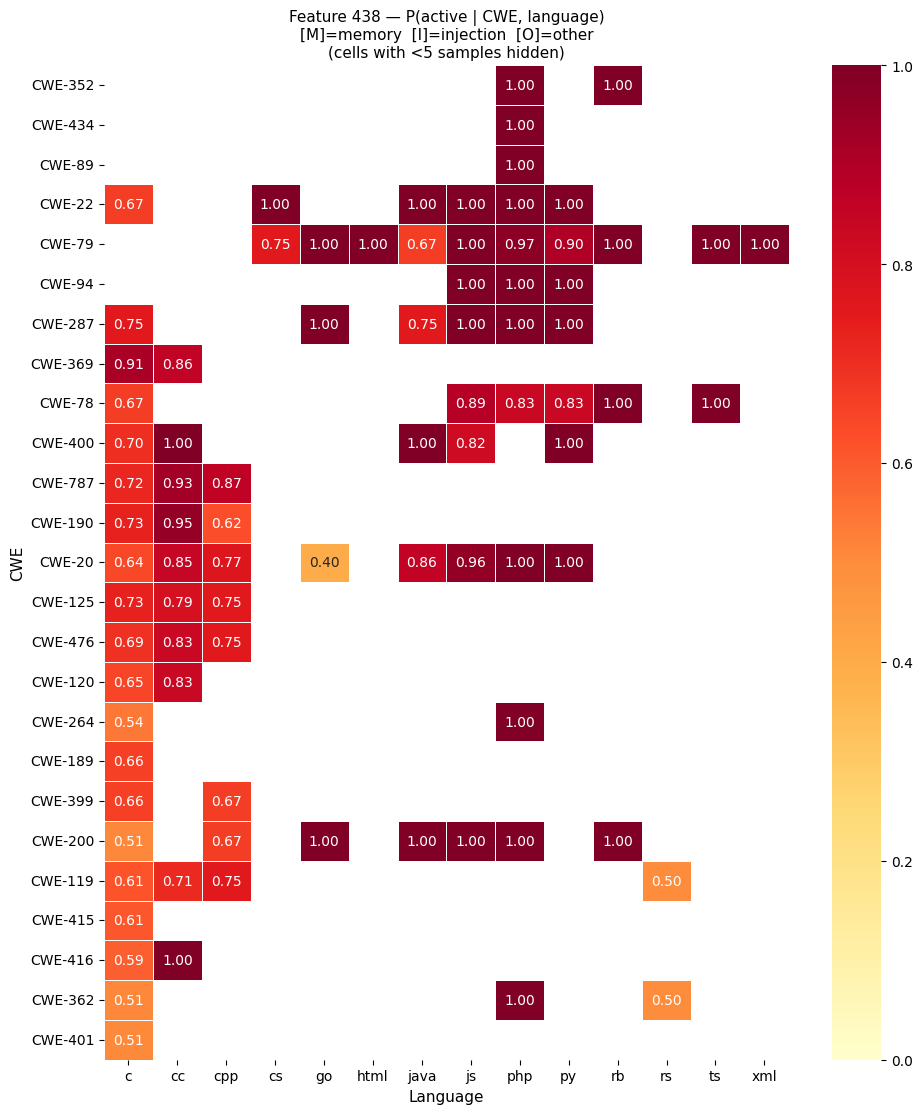

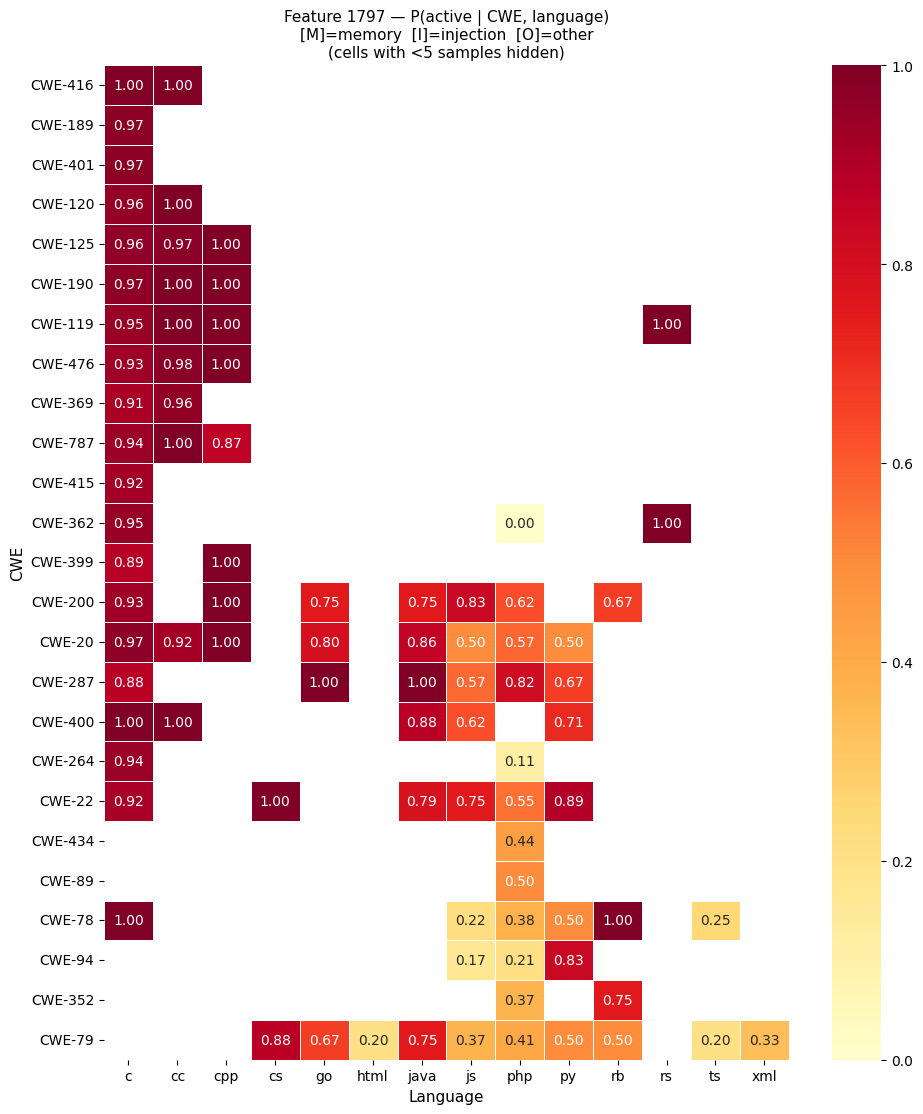

In [9]:
# Minimum samples per (CWE, lang) cell to include
MIN_SAMPLES = 5

for feat in FEATURES:
    act_col = f"f{feat}_active"
    pivot = (df.groupby(["cwe", "lang"])[act_col]
               .agg(["mean", "count"])
               .reset_index())
    # Filter sparse cells
    pivot = pivot[pivot["count"] >= MIN_SAMPLES]
    heatmap_data = pivot.pivot(index="cwe", columns="lang", values="mean")

    # Order rows by CWE family, then by mean activation
    cwe_order = (df.groupby("cwe")[act_col].mean()
                   .sort_values(ascending=False).index.tolist())
    heatmap_data = heatmap_data.reindex(
        [c for c in cwe_order if c in heatmap_data.index]
    )

    fig, ax = plt.subplots(figsize=(max(8, heatmap_data.shape[1]*0.7),
                                    max(6, heatmap_data.shape[0]*0.45)))
    sns.heatmap(
        heatmap_data,
        annot=True, fmt=".2f", cmap="YlOrRd",
        vmin=0, vmax=1, linewidths=0.4,
        mask=heatmap_data.isna(), ax=ax
    )

    # Add CWE-family annotations on y-axis
    for i, cwe in enumerate(heatmap_data.index):
        fam = ("[M]" if cwe in MEMORY_CWES
               else "[I]" if cwe in INJECTION_CWES
               else "[O]")
        ax.get_yticklabels()[i].set_text(f"{fam} {cwe}")

    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
    ax.set_title(f"Feature {feat} — P(active | CWE, language)\n"
                 "[M]=memory  [I]=injection  [O]=other\n"
                 f"(cells with <{MIN_SAMPLES} samples hidden)", fontsize=11)
    ax.set_xlabel("Language", fontsize=11)
    ax.set_ylabel("CWE", fontsize=11)
    plt.tight_layout()
    plt.savefig(f"cwe_domain_heatmap_f{feat}.png", dpi=150)
    plt.show()

---
## Part 5: GLM decomposition — language vs. CWE type

Fit logistic regression models to predict feature activation:

- **Model L** (language only): `active ~ language`
- **Model C** (CWE family only): `active ~ cwe_family`
- **Model L+C** (both): `active ~ language + cwe_family`

The incremental R² (pseudo) from adding CWE on top of language tells us how much CWE-type information is present *beyond* language.

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import OneHotEncoder
import warnings
warnings.filterwarnings("ignore")

def glm_decompose(df, feat, min_count=5):
    """Decompose activation variance into language vs. CWE-family contributions."""
    y = df[f"f{feat}_active"].values

    # Drop sparse cells
    lang_counts = df["lang"].value_counts()
    valid_langs = lang_counts[lang_counts >= min_count].index
    mask = df["lang"].isin(valid_langs)
    df_  = df[mask]
    y    = df_[f"f{feat}_active"].values

    enc_l = OneHotEncoder(sparse_output=False, drop="first")
    enc_c = OneHotEncoder(sparse_output=False, drop="first")

    X_lang = enc_l.fit_transform(df_[["lang"]])
    X_cwe  = enc_c.fit_transform(df_[["cwe_family"]])
    X_both = np.hstack([X_lang, X_cwe])

    def fit_auc(X):
        clf = LogisticRegression(max_iter=500, C=1.0)
        clf.fit(X, y)
        return roc_auc_score(y, clf.predict_proba(X)[:, 1])

    auc_l    = fit_auc(X_lang)
    auc_c    = fit_auc(X_cwe)
    auc_both = fit_auc(X_both)

    print(f"Feature {feat} — logistic regression AUC for predicting activation:")
    print(f"  Language only          : {auc_l:.4f}")
    print(f"  CWE family only        : {auc_c:.4f}")
    print(f"  Language + CWE family  : {auc_both:.4f}")
    print(f"  Δ AUC (CWE adds to lang): {auc_both - auc_l:+.4f}")
    print(f"  Δ AUC (lang adds to CWE): {auc_both - auc_c:+.4f}")
    print()
    if auc_l > 0.85:
        print(f"  → Language alone explains most activation → language detector.")
    if auc_c > 0.75 and (auc_both - auc_l) > 0.05:
        print(f"  → CWE family adds significant signal beyond language → CWE-domain detector.")
    if auc_c > 0.75 and auc_l < 0.75:
        print(f"  → CWE family is a stronger predictor than language alone → CWE-domain detector.")
    print()
    return {"feat": feat, "auc_lang": auc_l, "auc_cwe": auc_c, "auc_both": auc_both}

results = [glm_decompose(df, feat) for feat in FEATURES]

Feature 438 — logistic regression AUC for predicting activation:
  Language only          : 0.7210
  CWE family only        : 0.6501
  Language + CWE family  : 0.7349
  Δ AUC (CWE adds to lang): +0.0138
  Δ AUC (lang adds to CWE): +0.0847


Feature 1797 — logistic regression AUC for predicting activation:
  Language only          : 0.8394
  CWE family only        : 0.8157
  Language + CWE family  : 0.8492
  Δ AUC (CWE adds to lang): +0.0098
  Δ AUC (lang adds to CWE): +0.0335




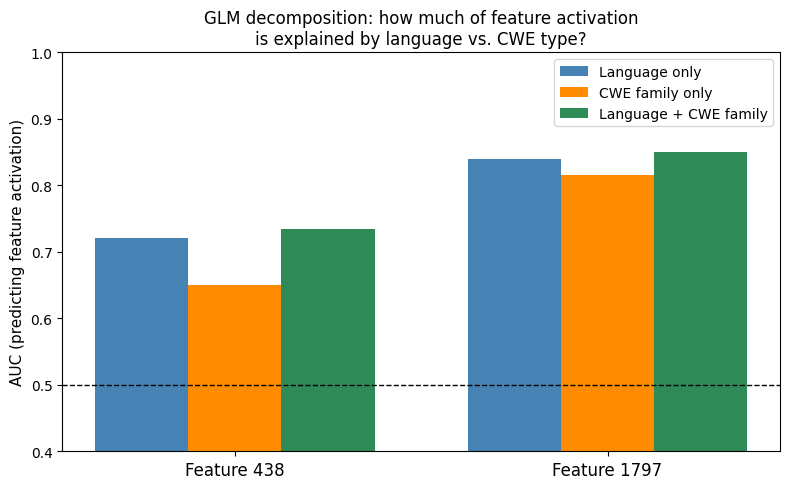

In [11]:
# Bar chart comparing AUC components
glm_df = pd.DataFrame(results)
x = np.arange(len(glm_df))
width = 0.25

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width, glm_df["auc_lang"], width, label="Language only",         color="steelblue")
ax.bar(x,         glm_df["auc_cwe"],  width, label="CWE family only",        color="darkorange")
ax.bar(x + width, glm_df["auc_both"], width, label="Language + CWE family",  color="seagreen")
ax.axhline(0.5, color="black", linestyle="--", lw=1)
ax.set_xticks(x)
ax.set_xticklabels([f"Feature {r['feat']}" for r in results], fontsize=12)
ax.set_ylabel("AUC (predicting feature activation)", fontsize=11)
ax.set_title("GLM decomposition: how much of feature activation\nis explained by language vs. CWE type?", fontsize=12)
ax.legend(fontsize=10)
ax.set_ylim(0.4, 1.0)
plt.tight_layout()
plt.savefig("cwe_domain_glm_decomposition.png", dpi=150)
plt.show()

---
## Part 6: The 'gold standard' cross-over samples

These are the small number of samples where language and CWE type point in *opposite directions*:

- **C code in injection CWEs** (e.g. a C CGI script with a SQL injection): feature 438 should fire IF it's a CWE detector, but NOT if it's a PHP detector.
- **Non-C code in memory CWEs** (Rust, Java with unsafe memory ops): feature 1797 should fire IF it's a memory-domain detector, but NOT if it's a C detector.

In [12]:
# Feature 438: C samples in injection CWEs vs PHP samples in injection CWEs
inj_c   = df[(df["cwe_family"] == "injection") & df["is_c"]]
inj_php = df[(df["cwe_family"] == "injection") & (df["lang"] == "php")]
inj_js  = df[(df["cwe_family"] == "injection") & (df["lang"].isin({"js","ts"}))]

print("Feature 438 — P(active) for injection CWEs by language:")
print(f"  PHP (n={len(inj_php):3d}): mean activation = {inj_php['f438_val'].mean():.4f}  "
      f"active rate = {inj_php['f438_active'].mean():.4f}")
print(f"  JS  (n={len(inj_js):3d}): mean activation = {inj_js['f438_val'].mean():.4f}  "
      f"active rate = {inj_js['f438_active'].mean():.4f}")
print(f"  C   (n={len(inj_c):3d}): mean activation = {inj_c['f438_val'].mean():.4f}  "
      f"active rate = {inj_c['f438_active'].mean():.4f}")
print()

if len(inj_c) > 0:
    print("C samples inside injection CWEs (gold-standard cross-over):")
    cross_c = df[(df["cwe_family"] == "injection") & df["is_c"]][["cwe", "lang", "f438_val", "f438_active", "label"]]
    print(cross_c.to_string(index=False))
    print()

    if len(inj_c) >= 2 and len(inj_php) >= 2:
        stat, p = mannwhitneyu(inj_php["f438_val"].values, inj_c["f438_val"].values,
                               alternative="two-sided")
        print(f"Mann-Whitney PHP vs C (within injection CWEs): p={p:.4f}")
        if p < 0.05:
            print("→ PHP activates feature 438 significantly more than C within injection CWEs → language confound.")
        else:
            print("→ No significant difference between PHP and C within injection CWEs → CWE-domain detector.")

Feature 438 — P(active) for injection CWEs by language:
  PHP (n=836): mean activation = 0.6278  active rate = 0.9761
  JS  (n=192): mean activation = 0.5425  active rate = 0.9896
  C   (n= 22): mean activation = 0.2983  active rate = 0.9091

C samples inside injection CWEs (gold-standard cross-over):
    cwe lang  f438_val  f438_active  label
 CWE-78   cc  0.097982            1      0
 CWE-78   cc  0.096760            1      1
 CWE-89    c  0.210199            1      0
 CWE-89    c  0.263307            1      1
CWE-434  cpp  0.502907            1      0
CWE-434  cpp  0.563430            1      1
 CWE-78    c  0.319451            1      0
 CWE-78    c  0.298500            1      1
 CWE-94    c  0.055036            1      0
 CWE-94    c  0.027834            1      1
 CWE-78    c  0.378629            1      0
 CWE-78    c  0.349202            1      1
 CWE-79    c  0.026918            1      0
 CWE-79    c  0.039460            1      1
 CWE-89  cpp  0.656808            1      0
 CWE-89  

In [13]:
# Feature 1797: non-C samples in memory CWEs vs C samples in memory CWEs
mem_c    = df[(df["cwe_family"] == "memory") & df["is_c"]]
mem_nonc = df[(df["cwe_family"] == "memory") & ~df["is_c"]]

print("Feature 1797 — P(active) for memory CWEs by language family:")
print(f"  C-family  (n={len(mem_c):4d}): mean activation = {mem_c['f1797_val'].mean():.4f}  "
      f"active rate = {mem_c['f1797_active'].mean():.4f}")
print(f"  non-C     (n={len(mem_nonc):4d}): mean activation = {mem_nonc['f1797_val'].mean():.4f}  "
      f"active rate = {mem_nonc['f1797_active'].mean():.4f}")
print()

if len(mem_nonc) > 0:
    print("Non-C samples inside memory CWEs (gold-standard cross-over):")
    cross_nonc = df[(df["cwe_family"] == "memory") & ~df["is_c"]][
        ["cwe", "lang", "f1797_val", "f1797_active", "label"]
    ]
    print(cross_nonc.to_string(index=False))
    print()

    if len(mem_nonc) >= 2 and len(mem_c) >= 2:
        stat, p = mannwhitneyu(mem_c["f1797_val"].values, mem_nonc["f1797_val"].values,
                               alternative="two-sided")
        print(f"Mann-Whitney C vs non-C (within memory CWEs): p={p:.4f}")
        if p < 0.05:
            print("→ C activates feature 1797 significantly more than non-C within memory CWEs → language confound.")
        else:
            print("→ No significant difference within memory CWEs → memory-domain detector.")

Feature 1797 — P(active) for memory CWEs by language family:
  C-family  (n=2396): mean activation = 0.4543  active rate = 0.9578
  non-C     (n=  40): mean activation = 0.2631  active rate = 0.7750

Non-C samples inside memory CWEs (gold-standard cross-over):
    cwe lang  f1797_val  f1797_active  label
CWE-787   rs   0.236420             1      0
CWE-787   rs   0.168959             1      1
CWE-125   rs   0.236420             1      0
CWE-125   rs   0.168959             1      1
CWE-125   js   0.000000             0      0
CWE-125   js   0.000000             0      1
CWE-416   rs   0.396922             1      0
CWE-416   rs   0.351273             1      1
CWE-119 java   0.168979             1      0
CWE-119 java   0.197870             1      1
CWE-190  php   0.000000             0      0
CWE-190  php   0.000000             0      1
CWE-119   rs   0.206054             1      0
CWE-119   rs   0.246940             1      1
CWE-119   rs   0.125244             1      0
CWE-119   rs   0.14

---
## Summary table

| Test | Feature 438 prediction if CWE-domain | Feature 1797 prediction if CWE-domain |
|---|---|---|
| Within-PHP: injection > non-injection | Significant diff | N/A |
| Within-C: memory > non-memory | N/A | Significant diff |
| Within-injection: PHP ≈ C | No significant lang diff | N/A |
| Within-memory: C ≈ non-C | N/A | No significant lang diff |
| GLM: CWE adds over language | ΔAUC > 0.05 | ΔAUC > 0.05 |
| C cross-over injection samples | F438 fires for C injection | — |
| Non-C cross-over memory samples | — | F1797 fires for non-C memory |

In [14]:
print("=" * 65)
print("FINAL SUMMARY")
print("=" * 65)

for feat, dom_lang, dom_family in [(438, PHP_JS_FAMILY, "injection"), (1797, C_FAMILY, "memory")]:
    val_col = f"f{feat}_val"
    act_col = f"f{feat}_active"

    dom_fam_rate  = df[df["cwe_family"] == dom_family][act_col].mean()
    other_fam_rate= df[df["cwe_family"] != dom_family][act_col].mean()
    dom_lang_rate = df[df["lang"].isin(dom_lang)][act_col].mean()
    other_lang_rate=df[~df["lang"].isin(dom_lang)][act_col].mean()

    print(f"\nFeature {feat} (hypothesis: {dom_family}-domain detector):")
    print(f"  P(active | {dom_family} CWE)       = {dom_fam_rate:.3f}")
    print(f"  P(active | other CWE)          = {other_fam_rate:.3f}")
    print(f"  P(active | dominant language)  = {dom_lang_rate:.3f}")
    print(f"  P(active | other language)     = {other_lang_rate:.3f}")
    print(f"  CWE-family lift   = {dom_fam_rate - other_fam_rate:+.3f}")
    print(f"  Language lift     = {dom_lang_rate - other_lang_rate:+.3f}")

FINAL SUMMARY

Feature 438 (hypothesis: injection-domain detector):
  P(active | injection CWE)       = 0.967
  P(active | other CWE)          = 0.709
  P(active | dominant language)  = 0.973
  P(active | other language)     = 0.695
  CWE-family lift   = +0.258
  Language lift     = +0.278

Feature 1797 (hypothesis: memory-domain detector):
  P(active | memory CWE)       = 0.955
  P(active | other CWE)          = 0.650
  P(active | dominant language)  = 0.954
  P(active | other language)     = 0.513
  CWE-family lift   = +0.305
  Language lift     = +0.441


---
## Part 7: P(feature | CWE) after removing language

We **residualize** each activation value by subtracting the mean activation for that language:

$$\text{resid}_{i} = \text{activation}_{i} - \overline{\text{activation}}_{\text{lang}(i)}$$

Aggregating residuals by CWE gives the CWE effect net of language.

- **Residual > 0 for a CWE** → that CWE activates the feature *more* than its language baseline → genuine CWE signal
- **Residual ≈ 0 for all CWEs** → language fully explains the activation; CWE adds nothing

We validate significance with a **permutation test**: shuffle CWE labels *within each language block* 5000 times
and check if the observed CWE spread in residuals is larger than chance.

In [15]:
# ── Residualize: subtract per-language mean ──────────────────────────────
for feat in FEATURES:
    val_col = f"f{feat}_val"
    res_col = f"f{feat}_resid"
    lang_mean = df.groupby("lang")[val_col].transform("mean")
    df[res_col] = df[val_col] - lang_mean

print("Language means removed. Residual columns added:")
for feat in FEATURES:
    res_col = f"f{feat}_resid"
    print(f"  f{feat}_resid  global mean={df[res_col].mean():.6f}  "
          f"std={df[res_col].std():.4f}  (should be ~0 mean by construction)")

Language means removed. Residual columns added:
  f438_resid  global mean=0.000000  std=0.2527  (should be ~0 mean by construction)
  f1797_resid  global mean=0.000000  std=0.2851  (should be ~0 mean by construction)


In [16]:
import numpy as np
from scipy.stats import kruskal

def cwe_residual_analysis(df, feat, n_permutations=5000, min_n=10):
    res_col = f"f{feat}_resid"

    # Per-CWE mean residual (= CWE effect net of language)
    cwe_res = (
        df.groupby("cwe")[res_col]
          .agg(["mean", "std", "count"])
          .rename(columns={"mean": "residual_mean",
                            "std":  "residual_std",
                            "count": "n"})
    )
    cwe_res = cwe_res[cwe_res["n"] >= min_n].copy()
    cwe_res["cwe_family"] = cwe_res.index.map(
        lambda c: "memory" if c in MEMORY_CWES
                  else "injection" if c in INJECTION_CWES
                  else "other"
    )
    cwe_res = cwe_res.sort_values("residual_mean", ascending=False)

    # Kruskal-Wallis across all CWEs (are residuals heterogeneous?)
    groups = [df[df["cwe"] == c][res_col].values
              for c in cwe_res.index]
    if len(groups) >= 2:
        kw_stat, kw_p = kruskal(*groups)
    else:
        kw_stat, kw_p = 0, 1.0

    # Permutation test: shuffle CWE within language blocks,
    # measure std(CWE group means) each time
    rng = np.random.default_rng(42)
    observed_spread = cwe_res["residual_mean"].std()

    perm_spreads = []
    df_perm = df[df["cwe"].isin(cwe_res.index)].copy()
    for _ in range(n_permutations):
        shuffled = df_perm.groupby("lang")["cwe"].transform(
            lambda x: rng.permutation(x.values)
        )
        perm_means = df_perm.groupby(shuffled)[res_col].mean()
        perm_spreads.append(perm_means.std())

    perm_spreads = np.array(perm_spreads)
    perm_p = (perm_spreads >= observed_spread).mean()

    print(f"\n{'='*60}")
    print(f"Feature {feat} — CWE residual analysis")
    print(f"{'='*60}")
    print(f"  Kruskal-Wallis across CWEs: H={kw_stat:.2f}  p={kw_p:.4f}")
    print(f"  Observed spread (std of CWE means): {observed_spread:.4f}")
    print(f"  Permutation p-value ({n_permutations} shuffles): {perm_p:.4f}")
    if perm_p < 0.05:
        print("  → CWE spread is larger than language-shuffled baseline "
              "→ genuine CWE signal exists beyond language.")
    else:
        print("  → CWE spread is within language-shuffled noise "
              "→ no reliable CWE signal beyond language.")
    print()
    print(cwe_res.to_string(float_format="{:+.4f}".format))
    return cwe_res

cwe_res_438  = cwe_residual_analysis(df, 438)
cwe_res_1797 = cwe_residual_analysis(df, 1797)


Feature 438 — CWE residual analysis
  Kruskal-Wallis across CWEs: H=120.25  p=0.0000
  Observed spread (std of CWE means): 0.0498
  Permutation p-value (5000 shuffles): 0.0000
  → CWE spread is larger than language-shuffled baseline → genuine CWE signal exists beyond language.

         residual_mean  residual_std    n cwe_family
cwe                                                 
CWE-434        +0.1162       +0.3649   62  injection
CWE-787        +0.0618       +0.2409  332     memory
CWE-94         +0.0590       +0.3319   64  injection
CWE-120        +0.0354       +0.2255   84     memory
CWE-79         +0.0337       +0.3273  774  injection
CWE-190        +0.0313       +0.2140  158     memory
CWE-352        +0.0281       +0.2770   60  injection
CWE-125        +0.0267       +0.2425  440     memory
CWE-415        +0.0205       +0.2346   70     memory
CWE-369        +0.0201       +0.1923  106     memory
CWE-476        +0.0168       +0.2448  360     memory
CWE-400        +0.0012       +0

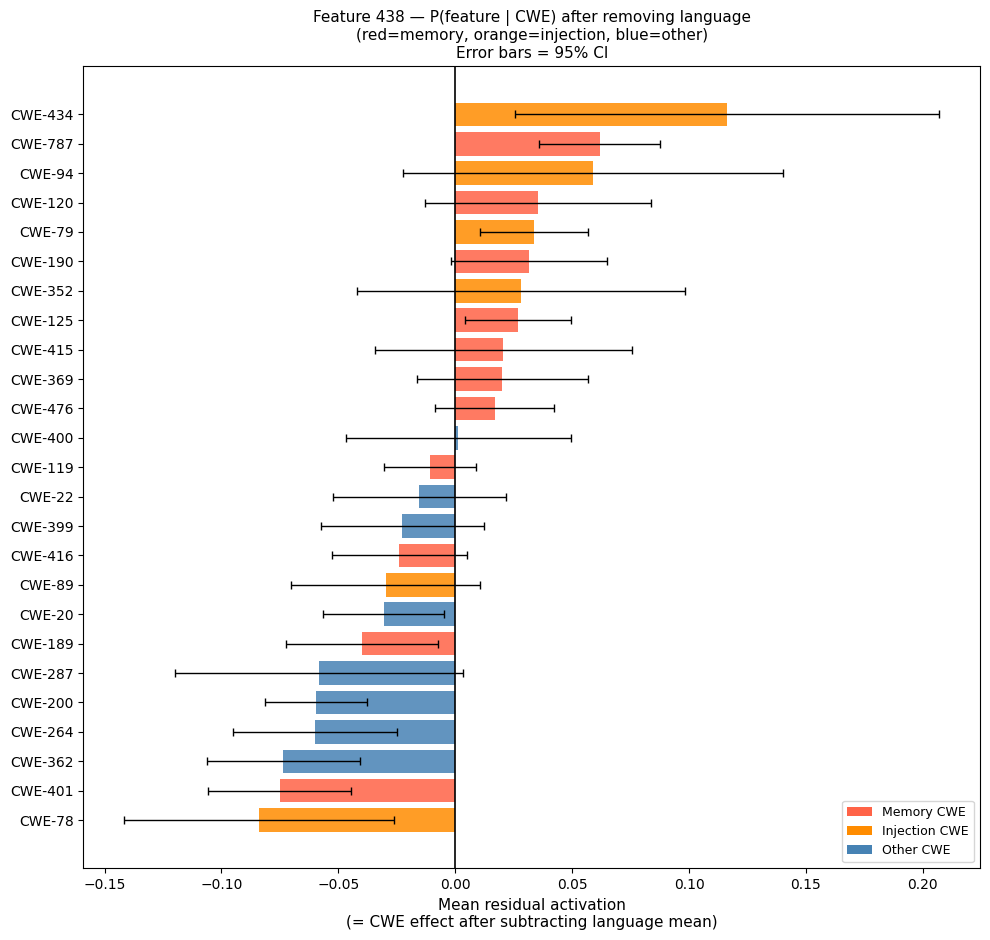

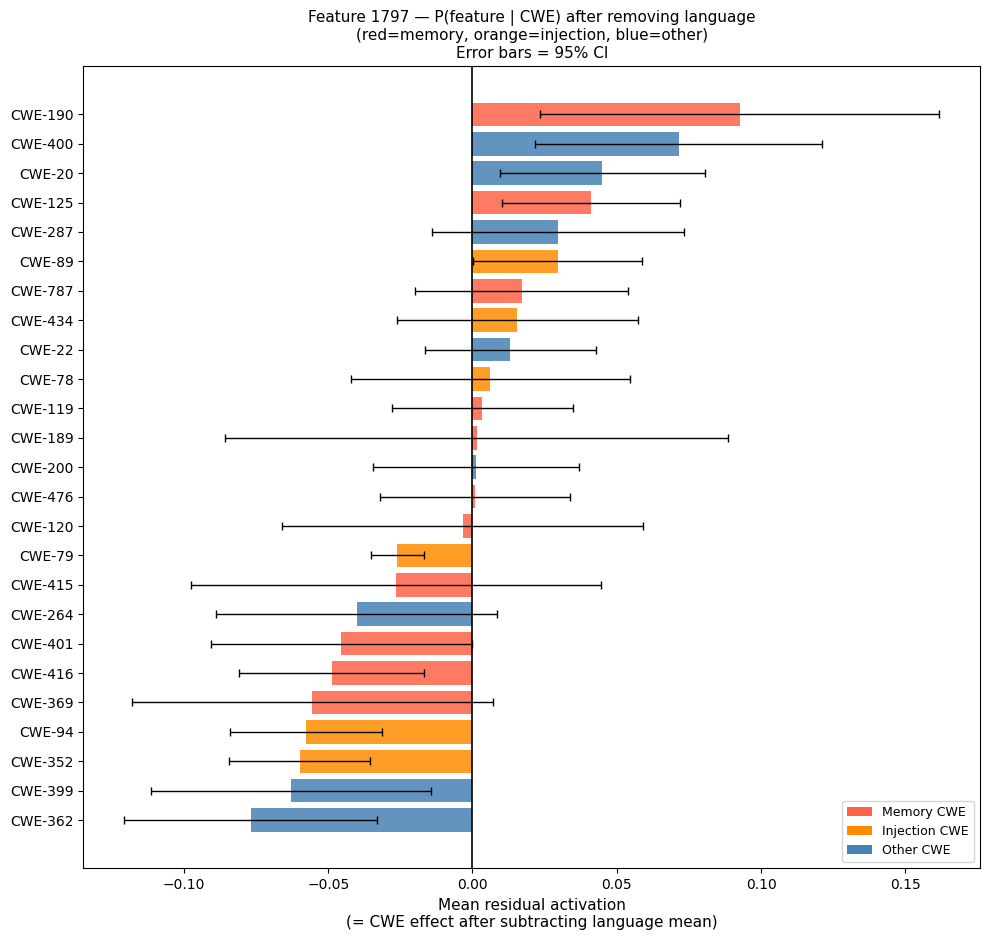

In [17]:
def plot_cwe_residuals(cwe_res, feat):
    fig, ax = plt.subplots(figsize=(10, max(5, len(cwe_res) * 0.38)))

    colors = cwe_res["cwe_family"].map(
        {"memory": "tomato", "injection": "darkorange", "other": "steelblue"}
    )
    bars = ax.barh(cwe_res.index, cwe_res["residual_mean"],
                   color=colors, alpha=0.85)

    # 95% CI error bars  (SE = std / sqrt(n))
    se = cwe_res["residual_std"] / np.sqrt(cwe_res["n"])
    ax.errorbar(
        cwe_res["residual_mean"], cwe_res.index,
        xerr=1.96 * se, fmt="none", color="black", capsize=3, lw=1
    )

    ax.axvline(0, color="black", lw=1.2)
    ax.set_xlabel("Mean residual activation\n(= CWE effect after subtracting language mean)",
                  fontsize=11)
    ax.set_title(
        f"Feature {feat} — P(feature | CWE) after removing language\n"
        "(red=memory, orange=injection, blue=other)\n"
        "Error bars = 95% CI",
        fontsize=11
    )
    ax.invert_yaxis()

    # Legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor="tomato",    label="Memory CWE"),
        Patch(facecolor="darkorange", label="Injection CWE"),
        Patch(facecolor="steelblue",  label="Other CWE"),
    ]
    ax.legend(handles=legend_elements, loc="lower right", fontsize=9)
    plt.tight_layout()
    plt.savefig(f"cwe_residual_f{feat}.png", dpi=150)
    plt.show()

plot_cwe_residuals(cwe_res_438,  438)
plot_cwe_residuals(cwe_res_1797, 1797)

In [18]:
cwe_res_1797

,residual_mean,residual_std,n,cwe_family
cwe,,,,
CWE-190,0.092536,0.443857,158,memory
CWE-400,0.071474,0.289111,130,other
CWE-20,0.045016,0.330198,334,other
CWE-125,0.040990,0.329216,440,memory
CWE-287,0.029573,0.191615,74,other
CWE-89,0.029566,0.193520,168,injection
CWE-787,0.017029,0.343887,332,memory
CWE-434,0.015513,0.167516,62,injection
CWE-22,0.013175,0.185435,152,other


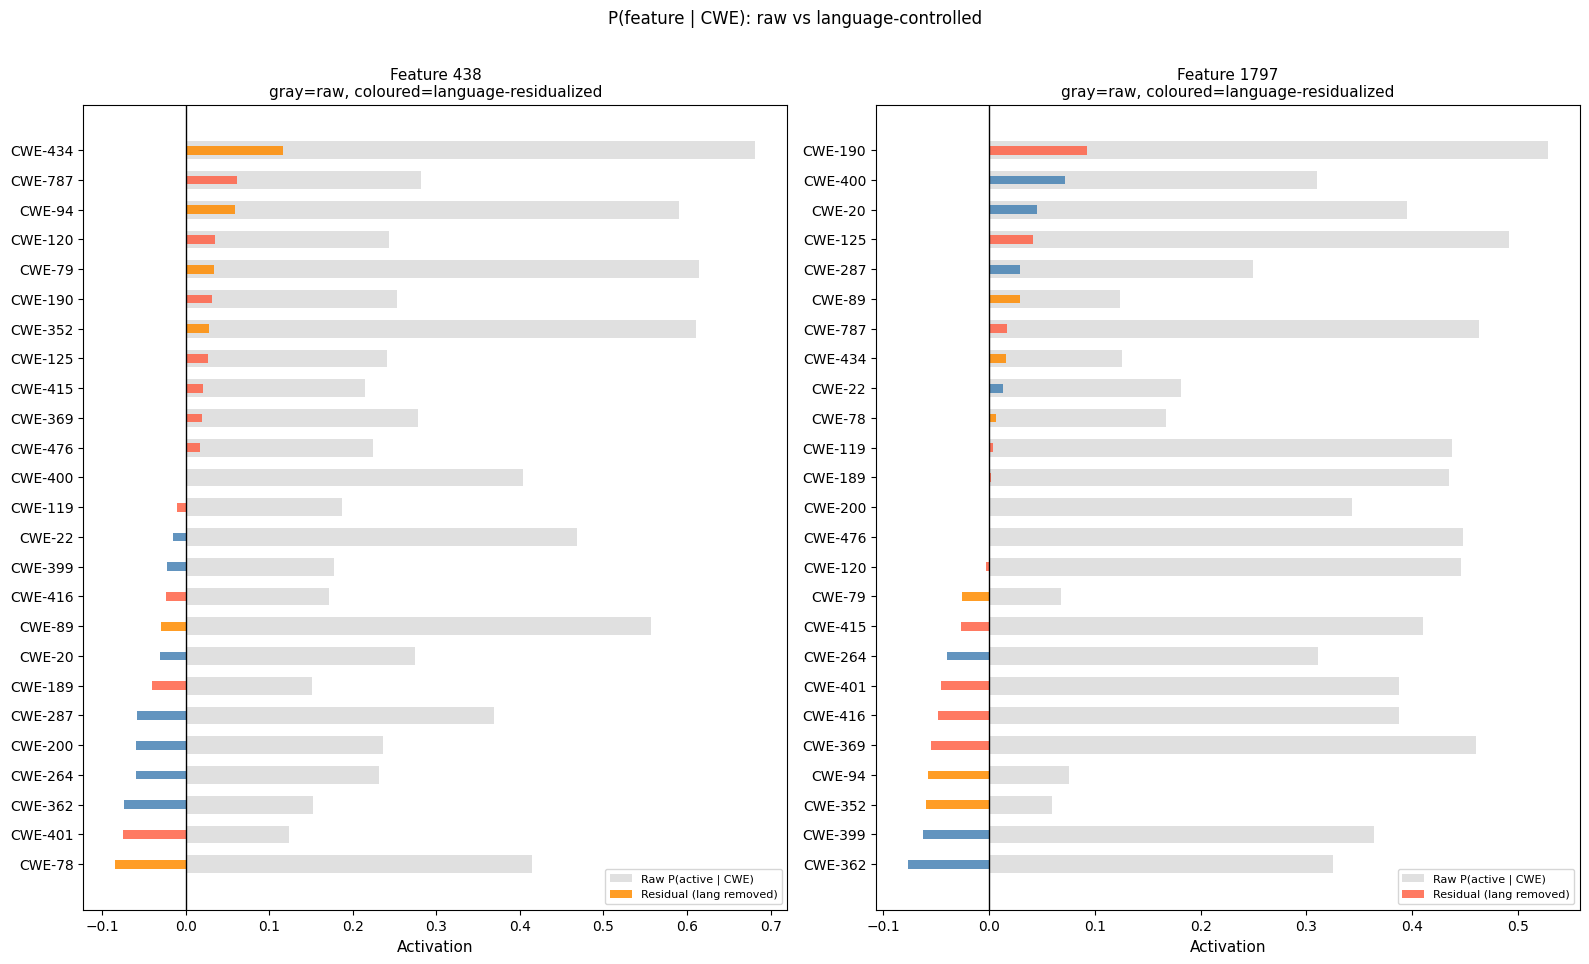

In [19]:
# Side-by-side summary: raw CWE activation vs language-residualized CWE activation
fig, axes = plt.subplots(1, 2, figsize=(16, max(6, len(cwe_res_438) * 0.38)))

for ax, cwe_res, feat in [(axes[0], cwe_res_438, 438),
                           (axes[1], cwe_res_1797, 1797)]:
    colors = cwe_res["cwe_family"].map(
        {"memory": "tomato", "injection": "darkorange", "other": "steelblue"}
    )
    # Raw CWE mean (in gray)
    raw_mean = df.groupby("cwe")[f"f{feat}_val"].mean().reindex(cwe_res.index)
    ax.barh(cwe_res.index, raw_mean, color="lightgray", alpha=0.7,
            label="Raw P(active | CWE)", height=0.6)
    # Residualized (coloured)
    ax.barh(cwe_res.index, cwe_res["residual_mean"], color=colors, alpha=0.85,
            label="Residual (lang removed)", height=0.3)
    ax.axvline(0, color="black", lw=1)
    ax.set_xlabel("Activation", fontsize=11)
    ax.set_title(f"Feature {feat}\ngray=raw, coloured=language-residualized",
                 fontsize=11)
    ax.invert_yaxis()
    ax.legend(fontsize=8)

plt.suptitle("P(feature | CWE): raw vs language-controlled", fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig("cwe_residual_comparison.png", dpi=150)
plt.show()

In [20]:
cwe_res

,residual_mean,residual_std,n,cwe_family
cwe,,,,
CWE-190,0.092536,0.443857,158,memory
CWE-400,0.071474,0.289111,130,other
CWE-20,0.045016,0.330198,334,other
CWE-125,0.040990,0.329216,440,memory
CWE-287,0.029573,0.191615,74,other
CWE-89,0.029566,0.193520,168,injection
CWE-787,0.017029,0.343887,332,memory
CWE-434,0.015513,0.167516,62,injection
CWE-22,0.013175,0.185435,152,other
